# Figure 4 Reproduction: Comparison of SGD Models

This notebook reproduces **Figure 4** from the paper *"SGD in the Large: Average-case Analysis, Asymptotics, and Stepsize Criticality"* (Paquette et al., 2021).

## Problem Setting

We consider the **Least Squares** optimization problem:

$$\min_{x \in \mathbb{R}^d} f(x) = \frac{1}{2n} \sum_{i=1}^{n} (a_i^\top x - b_i)^2 = \frac{1}{2n} \|Ax - b\|^2$$

where $A \in \mathbb{R}^{n \times d}$ is the data matrix and $b \in \mathbb{R}^n$ is the target vector.

## The Volterra Equation (Main Theoretical Result)

The paper's key contribution is showing that the expected loss $\mathbb{E}[f(x_t)]$ converges to a deterministic function $\psi_0(t)$ satisfying the **Volterra integral equation**:

$$\psi_0(t) = z(t) + r\gamma^2 \int_0^t h_2(t-s) \psi_0(s) \, ds$$

where:
- $\gamma$ is the (rescaled) learning rate
- $r = d/n$ is the aspect ratio
- $h_2(t)$ is a kernel function determined by the **eigenvalue distribution** of $\frac{1}{n}A^\top A$
- $z(t)$ encodes the initial conditions

## Objective

We compare **Empirical SGD** against several theoretical approximations:

| Model | Description |
|-------|-------------|
| **Volterra** | The proposed deterministic prediction from eigenvalues |
| **Streaming SGD** | One-pass SGD with fresh data at each step (infinite data limit) |
| **SME** | Stochastic Modified Equation - uses true gradient covariance |
| **SDE** | Stochastic Differential Equation with isotropic noise ($\Sigma = 0.01 \cdot I$) |

## Experimental Setup (Appendix F)

| Parameter | Value |
|-----------|-------|
| Samples $n$ | 1000 |
| Aspect ratio $r = d/n$ | 1.2 |
| Features $d$ | 1200 |
| Label noise $\tilde{R}$ | 0 (noiseless) |
| Step sizes | $\gamma_{\max} / \{8, 4, 2, 1.2\}$ |

**Data Models:**
1. **Isotropic Features**: $A_{ij} \sim \mathcal{N}(0, 1/n)$
2. **One-Hidden Layer**: $A = \sigma(XW)$ with shifted ReLU activation

In [30]:
import sys
import os

# Add the parent directory to path to import from src
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import provided modules
from src.sgd import LeastSquaresSGD, StreamingSGD
from src.volterra import VolterraSolver
from src.spectral import compute_eigenvalues
from src.random_features import generate_random_weights, compute_features, generate_isotropic_matrix

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Baseline Models: SDE and SME

### SGD Update Rule

The paper uses the following SGD update (Eq. 3):

$$x_{k+1} = x_k - \frac{\gamma}{n} \nabla f_{i_k}(x_k)$$

where $i_k$ is a uniformly sampled index. Note the $1/n$ scaling factor.

**Important**: Standard implementations use $x_{k+1} = x_k - \eta \nabla f_i(x_k)$, so we must set $\eta = \gamma/n$.

### SDE Model (Stochastic Differential Equation)

The SDE approximation assumes **isotropic noise** with fixed covariance $\Sigma$:

$$dX_t = -\nabla f(X_t) \, dt + \sqrt{\gamma \Sigma} \, dB_t$$

The paper uses $\Sigma = 0.01 \cdot I$. This model **underestimates** the true SGD noise because real gradient noise is state-dependent and anisotropic.

### SME Model (Stochastic Modified Equation)

The SME uses the **true empirical gradient covariance**:

$$\text{Cov}(\nabla f_i(x)) = \frac{1}{n} \sum_{i=1}^n \nabla f_i(x) \nabla f_i(x)^\top - \nabla f(x) \nabla f(x)^\top$$

This provides a better approximation than SDE but is computationally expensive. We use a diagonal approximation for efficiency.

In [31]:
def run_sde_simulation(A, b, x0, gamma, steps, sigma_val=0.1):
    """
    Simulates the SDE model.
    Paper: Sigma = 0.01 * I. This implies standard deviation scale is sqrt(0.01) = 0.1.
    
    Update rule approximating the discrete step:
    x_{k+1} = x_k - (gamma/n)*grad + (gamma/n)*sigma*z
    """
    n, d = A.shape
    x = x0.clone()
    losses = []
    
    # Effective step size for SGD step (gamma/n)
    eta = gamma / n
    
    # Noise standard deviation
    noise_std = sigma_val
    
    for _ in range(steps):
        residuals = A @ x - b
        full_grad = (A.T @ residuals) / n
        
        # Loss
        loss = (1.0 / (2 * n)) * torch.sum(residuals**2).item()
        losses.append(loss)
        
        # SDE Update
        noise = torch.randn_like(x) * noise_std
        x = x - eta * full_grad - eta * noise

    return np.array(losses)

def run_sme_simulation(A, b, x0, gamma, steps):
    """
    Simulates the SME (Diagonal Approximation).
    Noise scales with the empirical variance of the gradients.
    """
    n, d = A.shape
    x = x0.clone()
    losses = []
    
    eta = gamma / n
    
    for _ in range(steps):
        residuals = A @ x - b
        full_grad = (A.T @ residuals) / n
        
        loss = (1.0 / (2 * n)) * torch.sum(residuals**2).item()
        losses.append(loss)
        
        # --- Diagonal SME Variance Calculation ---
        # Var(g) = E[g^2] - (E[g])^2
        # g_i = e_i * a_i (where e_i is residual scalar)
        # All tensors kept as 1D [d]
        grads_sq_mean = ((A**2) * (residuals.unsqueeze(1)**2)).mean(dim=0)  # [d]
        grad_mean_sq = full_grad**2  # [d]
        grad_var = grads_sq_mean - grad_mean_sq
        grad_var = torch.clamp(grad_var, min=1e-12)
        grad_std = torch.sqrt(grad_var)
        
        # Sample noise
        noise = torch.randn_like(x) * grad_std
        
        # Update
        x = x - eta * full_grad - eta * noise
        
    return np.array(losses)

## 2. Global Parameters and Data Generation

### Simulation Parameters

We set $n=1000$ samples and aspect ratio $r=1.2$, giving $d = rn = 1200$ features.

The **overparameterized regime** ($r > 1$) is particularly interesting because:
- The system is underdetermined ($d > n$)
- Multiple solutions exist (interpolation is possible)
- The Volterra theory captures the implicit regularization of SGD

### Time Scaling

One **epoch** = $n$ SGD steps (one pass through data). We simulate for 50 epochs = 50,000 steps.

In [32]:
# Global Settings
n = 1000
r = 1.2
d = int(n * r)
num_epochs = 50
steps = n * num_epochs
num_runs = 5  # Averaging empirical runs for smoothness

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Simulation: n={n}, d={d} (r={r}), Epochs={num_epochs}, Device={device}")

Simulation: n=1000, d=1200 (r=1.2), Epochs=50, Device=cpu


### Data Generator

**Target Normalization**: We set $\|x^*\|^2 = 1$ so the initial signal strength is:

$$R = \|x_0 - x^*\|^2 = \|x^*\|^2 = 1$$

This ensures the **initial loss** is approximately:

$$f(x_0) = \frac{1}{2n}\|Ax^*\|^2 \approx \frac{1}{2}\|x^*\|^2 = 0.5$$

(using the fact that $\frac{1}{n}A^\top A \approx I$ for isotropic features)

**Data Models**:

1. **Isotropic**: $A_{ij} \sim \mathcal{N}(0, 1/n)$ — entries are i.i.d. Gaussian

2. **One-Hidden Layer**: 
$$A = \sigma(XW)$$
where $X \in \mathbb{R}^{n \times m}$ is random input, $W \in \mathbb{R}^{m \times d}$ is fixed random weights, and $\sigma$ is the shifted ReLU: $\sigma(z) = \max(0, z) - \mathbb{E}[\max(0, z)]$

In [33]:
def get_data(mode, n, d):
    """
    Generates Data (A, b) with NORMALIZED target x_star.
    We set ||x_star||^2 = 1 so R = 1.
    
    Returns 1D tensors for b, x0, x_star (required by SGD class).
    """
    if mode == 'isotropic':
        A = generate_isotropic_matrix(n, d)
        W = None
    elif mode == 'one_hidden':
        # One-hidden layer: A = sigma(X W)
        m = d
        X_raw = torch.randn(n, m)
        W = generate_random_weights(m, d)
        A = compute_features(X_raw, W, activation='shifted_relu')
    
    # Target x* - normalize to have norm 1 (R=1)
    raw_x = torch.randn(d)
    x_star = raw_x / torch.norm(raw_x)  # Shape: [d]
    
    b = A @ x_star  # Shape: [n]
    x0 = torch.zeros(d)  # Shape: [d]
    
    return A.to(device), b.to(device), x0.to(device), x_star.to(device), W

## 3. Experiment Loop

### Critical Step Size (Theorem 1.2)

The paper defines a **critical step size** $\gamma^*$ beyond which SGD may diverge. For the least squares problem:

$$\gamma_{\max} = \frac{2}{r} \cdot \frac{1}{\bar{\lambda}}$$

where $\bar{\lambda} = \frac{1}{d}\text{tr}(H) = \frac{1}{d}\sum_{i=1}^d \lambda_i$ is the mean eigenvalue of $H = \frac{1}{n}A^\top A$.

**Physical Interpretation**:
- $\gamma < \gamma_{\max}$: SGD converges exponentially
- $\gamma \approx \gamma_{\max}$: SGD reaches a noise floor (critical slowing down)
- $\gamma > \gamma_{\max}$: SGD diverges

### Step Sizes Tested

| Multiplier | Step Size | Expected Behavior |
|------------|-----------|-------------------|
| $1/8$ | $\gamma_{\max}/8$ | Fast convergence, low noise floor |
| $1/4$ | $\gamma_{\max}/4$ | Moderate convergence |
| $1/2$ | $\gamma_{\max}/2$ | Slower, higher noise floor |
| $1/1.2$ | $\gamma_{\max}/1.2 \approx 0.83\gamma_{\max}$ | Near critical, oscillatory |

### Learning Rate Scaling

**Critical Implementation Detail**: The SGD class uses standard notation where:
$$x_{k+1} = x_k - \eta \cdot \nabla f_i(x_k)$$

But the paper's $\gamma$ is defined via:
$$x_{k+1} = x_k - \frac{\gamma}{n} \nabla f_i(x_k)$$

Therefore: $\boxed{\eta = \gamma / n}$

In [34]:
def run_experiment(data_mode):
    # 1. Prepare Data
    A, b, x0, x_star, W_fixed = get_data(data_mode, n, d)
    if W_fixed is not None: W_fixed = W_fixed.to(device)

    # 2. Spectral Analysis
    print(f"[{data_mode}] Computing Eigenvalues...")
    eigvals = compute_eigenvalues(A)
    
    # Gamma Max Calculation (Thm 1.2)
    # gamma_max = 2/r * (mean(eigenvalues))^-1
    tr_H = np.sum(eigvals)
    mean_eig = tr_H / d
    gamma_max = (2.0 / r) * (1.0 / mean_eig)
    
    print(f"[{data_mode}] Mean Eval: {mean_eig:.4f}, Gamma Max: {gamma_max:.4f}")

    results = {}
    # Paper uses gamma_max/8, gamma_max/4, gamma_max/2, gamma_max/1.2
    multipliers = [1/8, 1/4, 1/2, 1/1.2]
    
    # Initial Signal R = ||x0 - x*||^2
    R_val = (torch.norm(x0 - x_star)**2).item()  # Should be 1.0
    
    for mult in multipliers:
        gamma = gamma_max * mult
        key = f"{mult}"
        print(f"  Running gamma = {gamma:.4f} ({mult:.4f}x)")
        
        # --- A. Volterra Theory ---
        solver = VolterraSolver(eigvals, gamma, r, R=R_val, R_tilde=0.0)
        psi, t_theory = solver.solve(t_max=num_epochs, dt=0.05)
        
        # --- B. Empirical SGD ---
        sgd_runs = []
        for _ in range(num_runs):
            # IMPORTANT: SGD class takes eta. We want eta = gamma/n
            model = LeastSquaresSGD(A, b, learning_rate=gamma/n, batch_size=1)
            loss_hist = model.train(steps)
            sgd_runs.append(loss_hist)
        sgd_mean = np.mean(sgd_runs, axis=0)
        sgd_std = np.std(sgd_runs, axis=0)
        
        # --- C. Streaming SGD ---
        def stream_gen(bs):
            if data_mode == 'isotropic':
                A_s = generate_isotropic_matrix(bs, d).to(device)
            else:
                m = d
                X_s = torch.randn(bs, m).to(device)
                A_s = compute_features(X_s, W_fixed, activation='shifted_relu')
            
            b_s = (A_s @ x_star).squeeze()
            return A_s, b_s

        streamer = StreamingSGD(d, gamma/n, stream_gen)
        streaming_loss = streamer.train(steps, A, b)
        
        # --- D. SME & SDE ---
        sme_loss = run_sme_simulation(A, b, x0, gamma, steps)
        sde_loss = run_sde_simulation(A, b, x0, gamma, steps, sigma_val=0.1)
        
        results[key] = {
            't_theory': t_theory,
            'psi': psi,
            'sgd_mean': sgd_mean,
            'sgd_std': sgd_std,
            'streaming': streaming_loss,
            'sme': sme_loss,
            'sde': sde_loss
        }
        
    return results

In [35]:
print("Running Isotropic Features Experiments...")
results_iso = run_experiment('isotropic')

print("\nRunning One-Hidden Layer Experiments...")
results_ohl = run_experiment('one_hidden')

Running Isotropic Features Experiments...
[isotropic] Computing Eigenvalues...
[isotropic] Mean Eval: 0.9996, Gamma Max: 1.6674
  Running gamma = 0.2084 (0.1250x)
  Running gamma = 0.4168 (0.2500x)
  Running gamma = 0.8337 (0.5000x)
  Running gamma = 1.3895 (0.8333x)

Running One-Hidden Layer Experiments...
[one_hidden] Computing Eigenvalues...
[one_hidden] Mean Eval: 0.3399, Gamma Max: 4.9040
  Running gamma = 0.6130 (0.1250x)
  Running gamma = 1.2260 (0.2500x)
  Running gamma = 2.4520 (0.5000x)
  Running gamma = 4.0867 (0.8333x)


## 4. Visualization (Figure 4)

### Expected Results

The plots should demonstrate:

1. **Volterra Accuracy**: The green curve (Volterra prediction) should closely track the orange curve (Empirical SGD mean), validating the theory.

2. **SDE Limitation**: The pink curve (SDE) hits a **noise floor** around $10^{-3}$ because isotropic noise overestimates diffusion when the loss is small.

3. **Streaming Advantage**: The blue curve (Streaming SGD) continues decreasing below the finite-sum noise floor because it never revisits data points (infinite data regime).

4. **SME Accuracy**: The teal curve (SME) tracks SGD well for small step sizes but may deviate for large $\gamma$.

5. **Critical Behavior**: At $\gamma \approx \gamma_{\max}$ (rightmost column), all methods show slower convergence and potential oscillations near the stability boundary.

### Plot Layout

- **Rows**: Data model (Isotropic vs One-Hidden Layer)
- **Columns**: Step size ($\gamma_{\max}/8$, $\gamma_{\max}/4$, $\gamma_{\max}/2$, $\gamma_{\max}/1.2$)
- **Y-axis**: Training loss (log scale)
- **X-axis**: Epochs (1 epoch = $n$ steps)

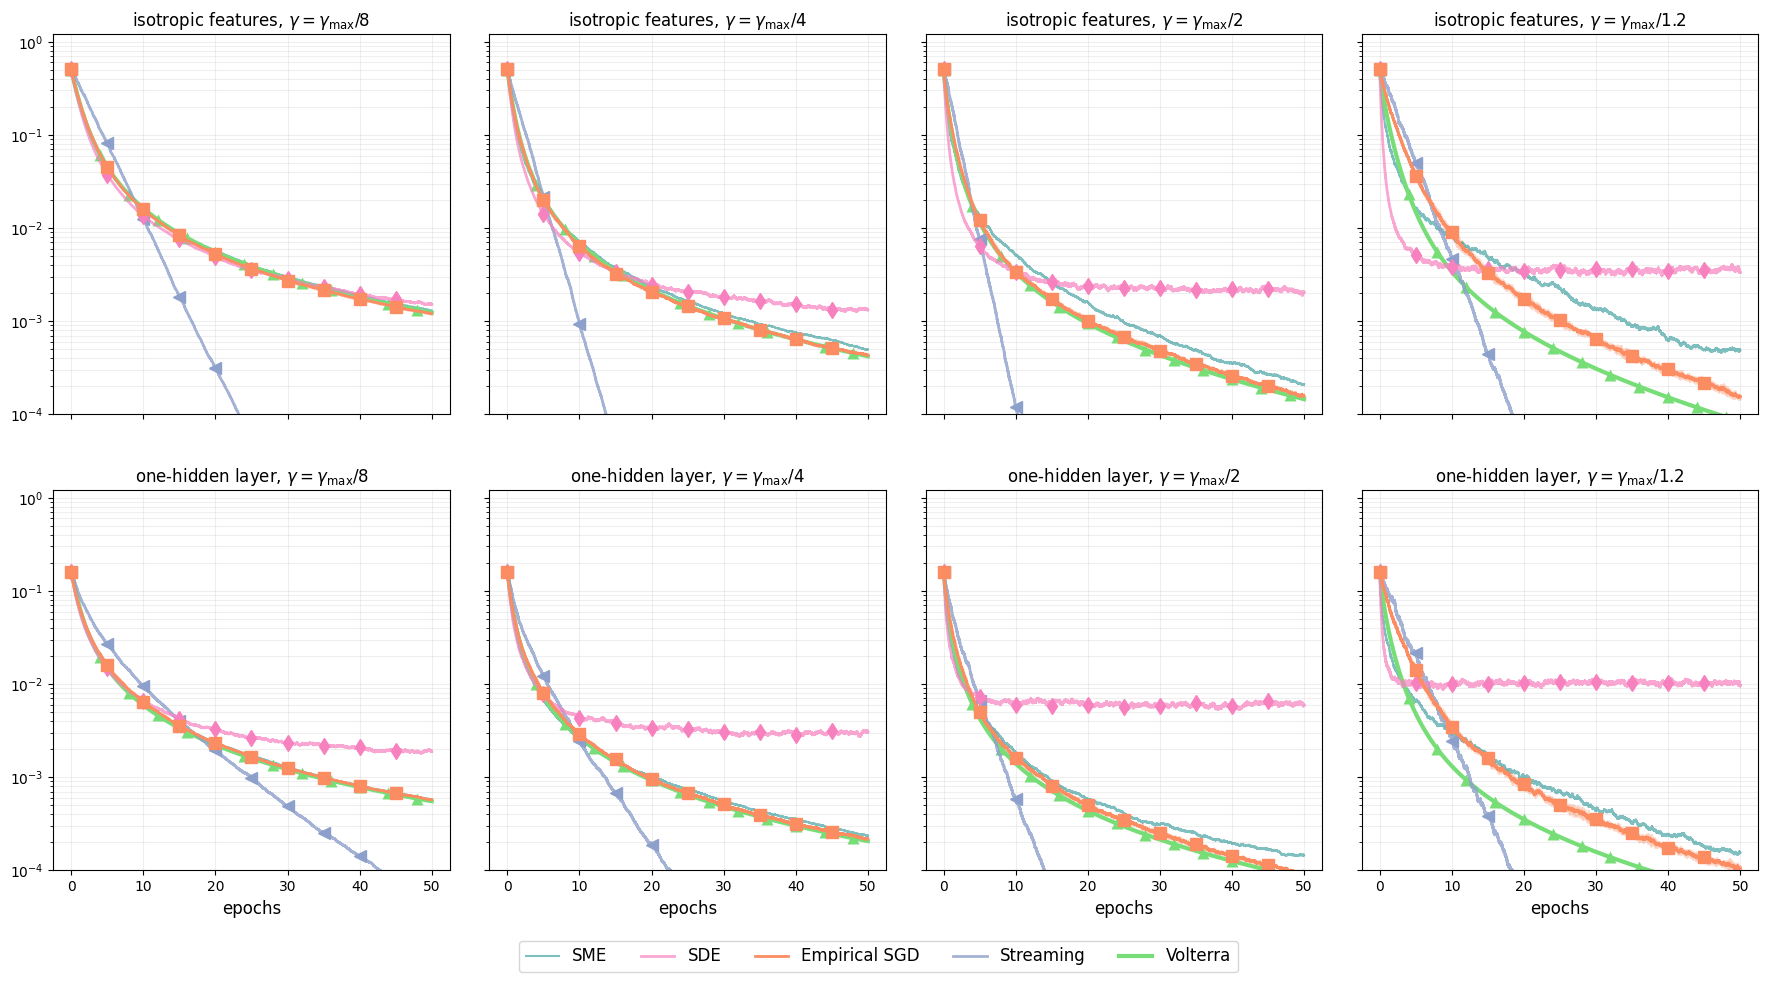

In [36]:
def plot_figure_4_corrected(results_iso, results_ohl):
    fig, axes = plt.subplots(2, 4, figsize=(22, 11), sharex=True, sharey=True)
    
    rows_data = [('isotropic features', results_iso), ('one-hidden layer', results_ohl)]
    # Updated keys to match new multipliers
    mult_keys = ['0.125', '0.25', '0.5', str(1/1.2)]
    mult_labels = [8, 4, 2, 1.2]  # Denominators for title
    
    for r_idx, (name, res) in enumerate(rows_data):
        for c_idx, k in enumerate(mult_keys):
            ax = axes[r_idx, c_idx]
            if k not in res: continue
            data = res[k]
            
            t_steps = np.linspace(0, num_epochs, len(data['sgd_mean']))
            
            # 1. SME (Teal) - Plot first to be in background
            ax.plot(t_steps, data['sme'], color='teal', lw=1.5, alpha=0.5, label='SME')
            
            # 2. Volterra (Green)
            ax.plot(data['t_theory'], data['psi'], color='#77DD77', lw=3, label='Volterra', alpha=1.0)
            ax.plot(data['t_theory'][::80], data['psi'][::80], '^', color='#77DD77', ms=8, markeredgecolor='none')
            
            # 3. Streaming (Blue)
            ax.plot(t_steps, data['streaming'], color='#8DA0CB', lw=2, alpha=0.8, label='Streaming')
            ax.plot(t_steps[::5000], data['streaming'][::5000], '<', color='#8DA0CB', ms=8)
            
            # 4. SDE (Pink)
            ax.plot(t_steps, data['sde'], color='#F781BF', lw=2, alpha=0.7, label='SDE')
            ax.plot(t_steps[::5000], data['sde'][::5000], 'd', color='#F781BF', ms=8)
            
            # 5. Empirical SGD (Orange)
            ax.plot(t_steps, data['sgd_mean'], color='#FC8D62', lw=2, label='Empirical SGD')
            ax.fill_between(t_steps, 
                            data['sgd_mean'] - data['sgd_std'], 
                            data['sgd_mean'] + data['sgd_std'], 
                            color='#FC8D62', alpha=0.3)
            ax.plot(t_steps[::5000], data['sgd_mean'][::5000], 's', color='#FC8D62', ms=8)
            
            ax.set_yscale('log')
            ax.set_ylim(1e-4, 1.2)
            ax.grid(True, which='both', alpha=0.2)
            
            # Title with denominator format
            title_str = f"{name}, $\\gamma=\\gamma_{{\\max}}/{mult_labels[c_idx]}$"
            ax.set_title(title_str, fontsize=12)
            if r_idx == 1: ax.set_xlabel('epochs', fontsize=12)

    # Legend
    handles, labels = axes[0,0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ordered_labels = ['SME', 'SDE', 'Empirical SGD', 'Streaming', 'Volterra']
    ordered_handles = [by_label[l] for l in ordered_labels if l in by_label]
    
    fig.legend(ordered_handles, ordered_labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.02), fontsize=12)
    plt.subplots_adjust(bottom=0.12, wspace=0.1, hspace=0.2)
    plt.show()

plot_figure_4_corrected(results_iso, results_ohl)